---
title: Implementasi Transformasi
date: 2026-04-12
---

Implementasi Visualisasi Transformasi Linear Refleksi pada Vektor di Bidang Dua Dimensi

Konsep Matematis yang Diwujudkan
Sebuah titik dalam bidang dua dimensi dapat direpresentasikan sebagai vektor posisi
$$\mathbf{v} = \begin{pmatrix} x \\ y \end{pmatrix}.$$
Transformasi refleksi terhadap garis cermin $  x = 0  $ (sumbu $  y  $) didefinisikan sebagai fungsi linear $  T: \mathbb{R}^2 \to \mathbb{R}^2  $ dengan aturan
$$T(x, y) = (-x, y).$$
Dalam notasi matriks, transformasi ini dinyatakan oleh matriks transformasi
$$A = \begin{pmatrix} -1 & 0 \\ 0 & 1 \end{pmatrix},$$
sehingga citra dari setiap vektor $  \mathbf{v}  $ dapat ditulis secara ringkas sebagai
$$T(\mathbf{v}) = A\mathbf{v}.$$
Dalam simulasi yang dibangun, empat titik pembentuk persegi panjang—yaitu A(−4, 4), B(−2, 4), C(−4, 2), dan D(−2, 2)—digunakan sebagai representasi vektor-vektor posisi. Saat persegi panjang biru digeser secara interaktif melalui operasi drag, setiap vektor posisi mengalami perubahan menjadi $  \mathbf{v}' = (x', y')  $. Program kemudian secara otomatis menghitung citra refleksinya menjadi
$$\mathbf{v}'' = (-x', y'),$$
sehingga persegi panjang merah (citra) selalu berada dalam posisi simetris terhadap garis cermin dengan jarak yang identik.
Sifat-Sifat Transformasi Linear yang Tergambarkan
Visualisasi interaktif ini secara langsung mengilustrasikan beberapa sifat penting transformasi linear, antara lain:

Konservasi garis lurus: sisi-sisi persegi panjang tetap berupa segmen garis lurus setelah transformasi.
Konservasi paralelisme: sisi-sisi yang semula paralel tetap paralel.
Konservasi panjang: panjang setiap sisi tidak berubah (meskipun arah dapat terbalik).
Konservasi sudut: persegi panjang tetap mempertahankan bentuk persegi panjang.
Inversi orientasi: arah “kiri–kanan” menjadi terbalik, meskipun garis cermin sendiri bersifat tetap (eigenvector dengan eigenvalue 1).

Garis cermin $  x = 0  $ berperan sebagai himpunan titik tetap, yang secara geometris sesuai dengan sifat homogen transformasi linear.

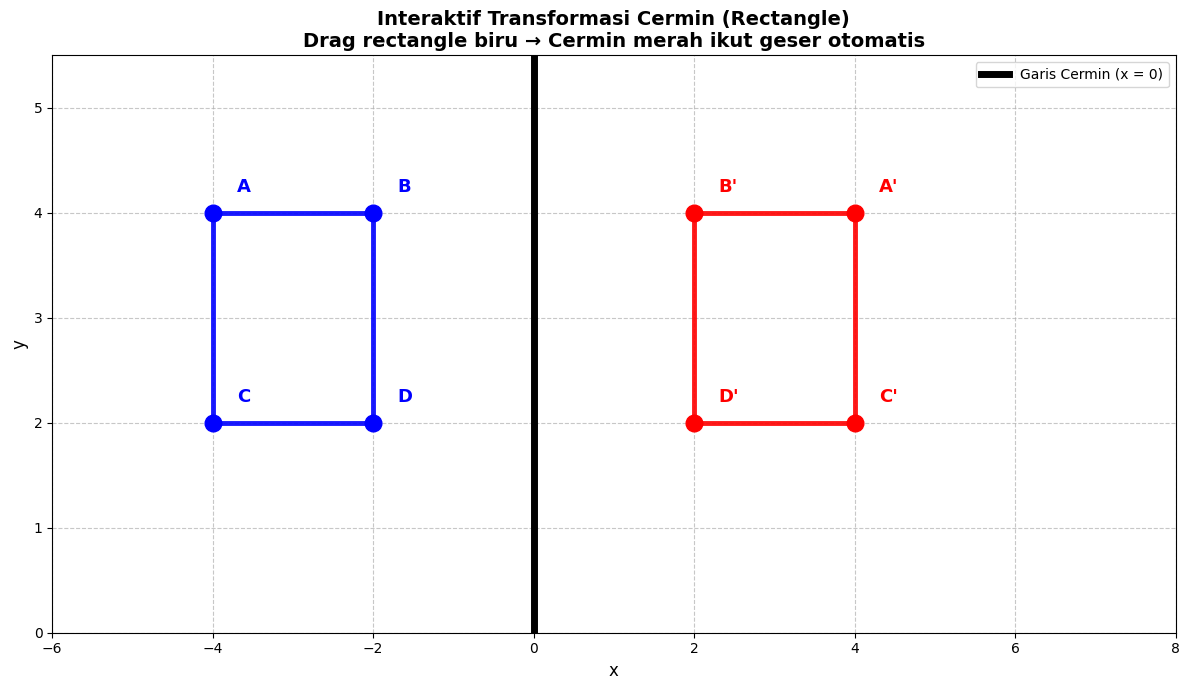

In [15]:
import matplotlib.pyplot as plt

class InteractiveMirror:
    def __init__(self):
        self.fig, self.ax = plt.subplots(figsize=(12, 7))
        self.ax.set_title('Interaktif Transformasi Cermin (Rectangle)\n'
                          'Drag rectangle biru → Cermin merah ikut geser otomatis', 
                         fontsize=14, fontweight='bold')
        self.ax.set_xlim(-6, 8)
        self.ax.set_ylim(0, 5.5)
        self.ax.set_xlabel('x', fontsize=12)
        self.ax.set_ylabel('y', fontsize=12)
        self.ax.grid(True, linestyle='--', alpha=0.7)


        self.mirror = self.ax.axvline(x=0, color='black', linewidth=5, label='Garis Cermin (x = 0)')


        self.original_pos = {
            'A': [-4.0, 4.0],   # top-left
            'B': [-2.0, 4.0],   # top-right
            'C': [-4.0, 2.0],   # bottom-left
            'D': [-2.0, 2.0]    # bottom-right
        }

        self.original_points = {}
        self.original_labels = {}

        for label, (x, y) in self.original_pos.items():
            point, = self.ax.plot(x, y, 'o', color='blue', markersize=12, picker=True, pickradius=12)
            text = self.ax.text(x + 0.3, y + 0.2, label, fontsize=13, fontweight='bold', color='blue')
            self.original_points[label] = point
            self.original_labels[label] = text


        self.original_rect_lines = []
        sides = [('A', 'B'), ('B', 'D'), ('D', 'C'), ('C', 'A')]
        for p1, p2 in sides:
            x1, y1 = self.original_pos[p1]
            x2, y2 = self.original_pos[p2]
            line, = self.ax.plot([x1, x2], [y1, y2], color='blue', linewidth=3.5, alpha=0.9)
            self.original_rect_lines.append((line, p1, p2))


        self.reflected_points = {}
        self.reflected_labels = {}
        self.reflected_rect_lines = []
        self.update_reflected()


        self.fig.canvas.mpl_connect('pick_event', self.on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)

        self.dragging = False
        self.current_label = None
        self.drag_start_mouse = None
        self.drag_start_pos = None

        self.ax.legend()
        plt.tight_layout()
        plt.show()

    def update_reflected(self):
        for artist in list(self.reflected_points.values()) + list(self.reflected_labels.values()):
            try:
                artist.remove()
            except:
                pass
        for line in self.reflected_rect_lines:
            try:
                line.remove()
            except:
                pass

        self.reflected_points.clear()
        self.reflected_labels.clear()
        self.reflected_rect_lines.clear()

        for label, (x, y) in self.original_pos.items():
            rx, ry = -x, y
            point, = self.ax.plot(rx, ry, 'o', color='red', markersize=12)
            text = self.ax.text(rx + 0.3, ry + 0.2, label + "'", fontsize=13, fontweight='bold', color='red')
            self.reflected_points[label] = point
            self.reflected_labels[label] = text

        sides = [('A', 'B'), ('B', 'D'), ('D', 'C'), ('C', 'A')]
        for p1, p2 in sides:
            rx1, ry1 = -self.original_pos[p1][0], self.original_pos[p1][1]
            rx2, ry2 = -self.original_pos[p2][0], self.original_pos[p2][1]
            line, = self.ax.plot([rx1, rx2], [ry1, ry2], color='red', linewidth=3.5, alpha=0.9)
            self.reflected_rect_lines.append(line)

    def update_original_visuals(self):
        for label, (x, y) in self.original_pos.items():
            self.original_points[label].set_data([x], [y])
            self.original_labels[label].set_position((x + 0.3, y + 0.2))

        for line, p1, p2 in self.original_rect_lines:
            x1, y1 = self.original_pos[p1]
            x2, y2 = self.original_pos[p2]
            line.set_data([x1, x2], [y1, y2])

    def on_pick(self, event):
        for label, artist in self.original_points.items():
            if artist == event.artist:
                self.dragging = True
                self.current_label = label
                self.drag_start_mouse = (event.mouseevent.xdata, event.mouseevent.ydata)
                self.drag_start_pos = {lbl: pos[:] for lbl, pos in self.original_pos.items()}
                return

    def on_motion(self, event):
        if not self.dragging or event.xdata is None or event.ydata is None:
            return

        dx = event.xdata - self.drag_start_mouse[0]
        dy = event.ydata - self.drag_start_mouse[1]

        for label in self.original_pos:
            sx, sy = self.drag_start_pos[label]
            self.original_pos[label] = [sx + dx, sy + dy]

        self.update_original_visuals()

        self.update_reflected()

        self.fig.canvas.draw_idle()

    def on_release(self, event):
        self.dragging = False
        self.current_label = None
        self.drag_start_mouse = None
        self.drag_start_pos = None


if __name__ == "__main__":
    InteractiveMirror()

<!-- 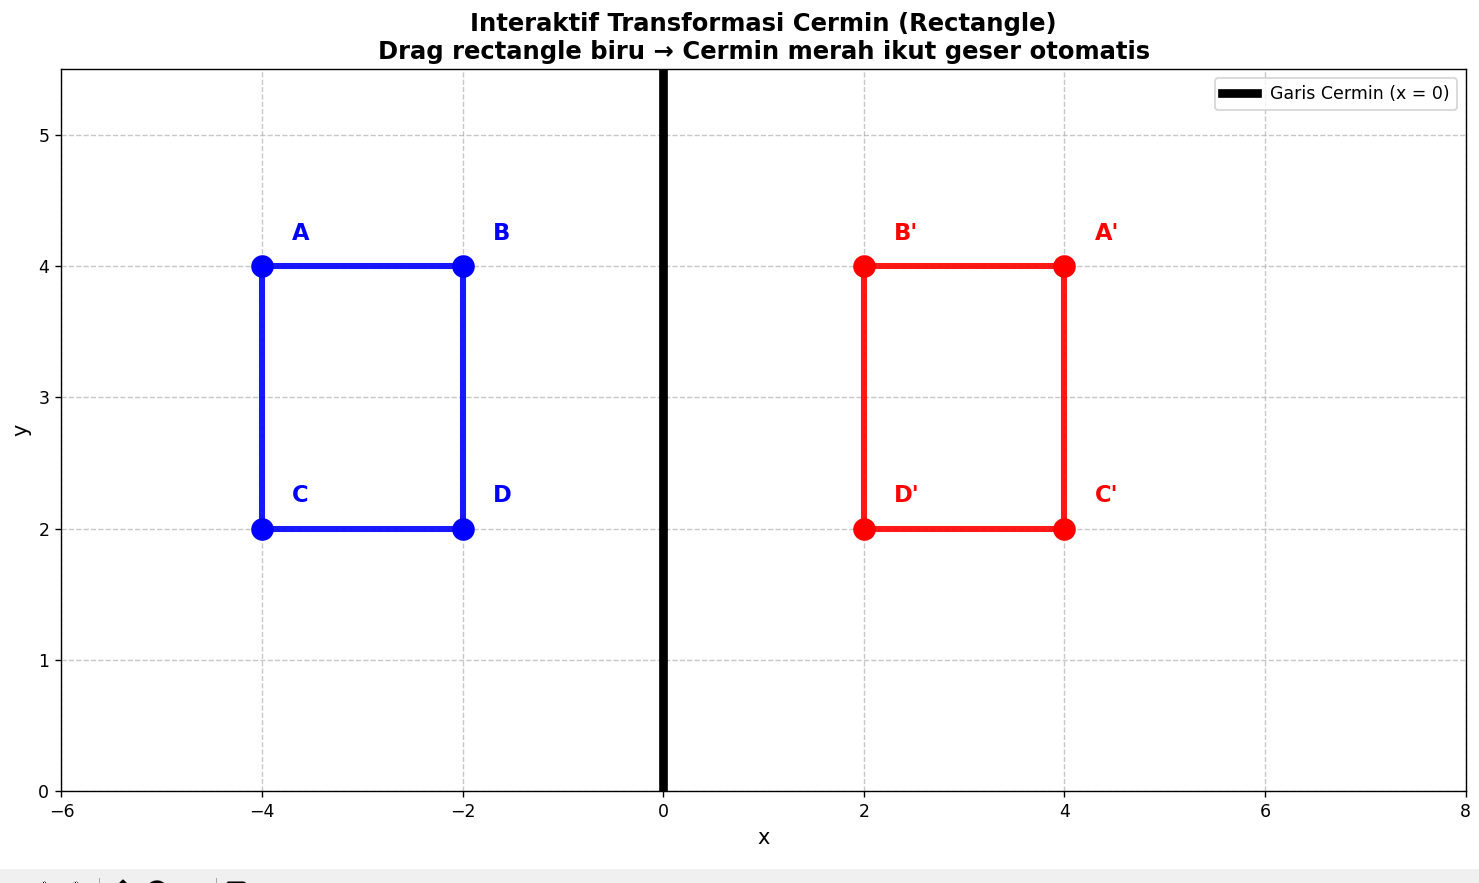 -->